In [31]:
'ciao'

'ciao'

In [32]:
import os
import os.path as osp
if osp.split(os.getcwd())[-1] == 'notebooks':
    os.chdir('..')

os.getcwd()

'e:\\Edoardo\\Education\\SportDataCampus\\ScoutingAgent'

In [33]:
import os
import uuid
from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import Image, display, Markdown

from google.cloud import bigquery
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage, AIMessage

from services.llm_factory import create_graph_llm
from services.runtime_secrets import get_secret
from visualization.scouting_viz import fetch_match_shots_for_player, plot_shot_map_vertical

# Config base
PROJECT_ID = get_secret("GCP_PROJECT_ID") or "YOUR_GCP_PROJECT_ID"
DATASET = get_secret("BQ_DATASET", "scouting_agent")
OUT_DIR = Path("notebooks/_agent_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)



In [34]:
import os
import json
from pathlib import Path
from google.oauth2 import service_account

from services.runtime_secrets import get_secret, parse_service_account_info

# 1) Project esplicito (evita "Unable to find your project")
project_id = get_secret("GCP_PROJECT_ID", "sport-data-campus").strip()
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
os.environ["GCP_PROJECT"] = project_id

# 2) Converte il JSON credenziale (preso da secrets) in file temporaneo
raw_sa = get_secret("GOOGLE_APPLICATION_CREDENTIALS", "").strip()
if raw_sa.startswith("{"):
    sa_info = parse_service_account_info(raw_sa)
    creds_path = Path(".secrets") / "adc_from_streamlit.json"
    creds_path.parent.mkdir(parents=True, exist_ok=True)
    creds_path.write_text(json.dumps(sa_info), encoding="utf-8")
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = str(creds_path.resolve())
else:
    # se già è un path vero, lo usa così com'è
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = raw_sa

# 3) Sanity check rapido
_ = service_account.Credentials.from_service_account_file(
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"]
)
print("ADC OK:", os.environ["GOOGLE_APPLICATION_CREDENTIALS"])
print("PROJECT OK:", os.environ["GOOGLE_CLOUD_PROJECT"])

ADC OK: E:\Edoardo\Education\SportDataCampus\ScoutingAgent\.secrets\vertexai-wyscout.json
PROJECT OK: sport-data-campus


In [ ]:
import os
from pathlib import Path
import re

sa_path = Path(".secrets/vertexai-wyscout.json").resolve()
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = str(sa_path)
os.environ["GOOGLE_CLOUD_PROJECT"] = "sport-data-campus"
os.environ["GCP_PROJECT"] = "sport-data-campus"
os.environ["VERTEX_LOCATION"] = "europe-west1"
os.environ["VERTEX_MODEL_NAME"] = "gemini-2.5-flash-lite"  # o pro se abilitato

In [36]:
from services.llm_factory import create_graph_llm
llm = create_graph_llm()

In [37]:
def _sanitize_sql(sql: str) -> str:
    s = sql.strip().rstrip(";")
    low = s.lower()
    blocked = ("insert ", "update ", "delete ", "merge ", "drop ", "truncate ", "alter ", "create ")
    if any(tok in low for tok in blocked):
        raise ValueError("Only read-only SQL is allowed.")
    if " limit " not in low:
        s += " LIMIT 200"
    return s


@tool
def run_bigquery_sql(sql: str) -> str:
    """Esegue SQL read-only su BigQuery; anteprima senza tabulate."""
    sql = _sanitize_sql(sql)
    client = bigquery.Client(project=PROJECT_ID)
    df = client.query(sql).to_dataframe()
    if df.empty:
        return "Query OK. 0 righe."
    preview = df.head(20).to_string(index=False)
    return f"Righe: {len(df)}\n\nAnteprima (prime 20):\n{preview}"


@tool
def create_shot_map(player_id: int, match_id: int, title: str = "") -> str:
    """Shot map stile scouting_viz; restituisce path machine-readable per il notebook."""
    pack = fetch_match_shots_for_player(
        int(player_id),
        int(match_id),
        project_id=PROJECT_ID or None,
        dataset=DATASET,
    )
    df = pack.get("shots", pd.DataFrame())
    if df.empty:
        return f"Nessun tiro per player_id={player_id}, match_id={match_id}."

    final_title = title or f"Shot map — player {player_id} / match {match_id}"
    fig, _ = plot_shot_map_vertical(
        df,
        final_title,
        team_img_source=pack.get("team_image_data_url"),
        player_img_source=pack.get("player_image_data_url"),
    )

    out_path = OUT_DIR / f"shot_map_{player_id}_{match_id}_{uuid.uuid4().hex[:8]}.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

    goals = int(df["shot_is_goal"].fillna(False).astype(bool).sum()) if "shot_is_goal" in df.columns else 0
    xg = float(pd.to_numeric(df.get("shot_xg"), errors="coerce").fillna(0).sum()) if "shot_xg" in df.columns else 0.0

    return (
        f"SHOT_MAP_PATH={out_path.resolve().as_posix()}\n"
        f"shots={len(df)} goals={goals} xg_total={xg:.3f}\n"
        f"Usa questi numeri nel commento sintetico per l'utente."
    )


tools = [run_bigquery_sql, create_shot_map]
llm_with_tools = llm.bind_tools(tools)

In [38]:
def run_data_agent(user_prompt: str, max_steps: int = 8) -> tuple[str, list]:
    messages: list = [HumanMessage(content=user_prompt)]
    tool_by_name = {t.name: t for t in tools}

    for _ in range(max_steps):
        ai_msg: AIMessage = llm_with_tools.invoke(messages)
        messages.append(ai_msg)

        tool_calls = getattr(ai_msg, "tool_calls", None) or []
        if not tool_calls:
            text = ai_msg.content if isinstance(ai_msg.content, str) else str(ai_msg.content)
            return text.strip(), messages

        for tc in tool_calls:
            name = tc["name"]
            args = tc.get("args") or {}
            fn = tool_by_name.get(name)
            try:
                result = fn.invoke(args) if fn else f"Tool sconosciuto: {name}"
            except Exception as e:
                result = f"Errore tool: {e}"
            messages.append(
                ToolMessage(content=str(result), tool_call_id=tc["id"], name=name)
            )

    return "max_steps: interrompo qui.", messages

In [39]:
SHOT_MAP_PATH_RE = re.compile(r"^SHOT_MAP_PATH=(.+)$", re.MULTILINE)


def render_agent_response(answer: str, messages: list) -> None:
    display(Markdown(answer))

    paths: list[str] = []
    for m in messages:
        if isinstance(m, ToolMessage) and m.content:
            paths.extend(SHOT_MAP_PATH_RE.findall(m.content))

    for p in paths:
        display(Image(filename=p.strip()))

I dati richiesti non sono disponibili. Riprova più tardi.

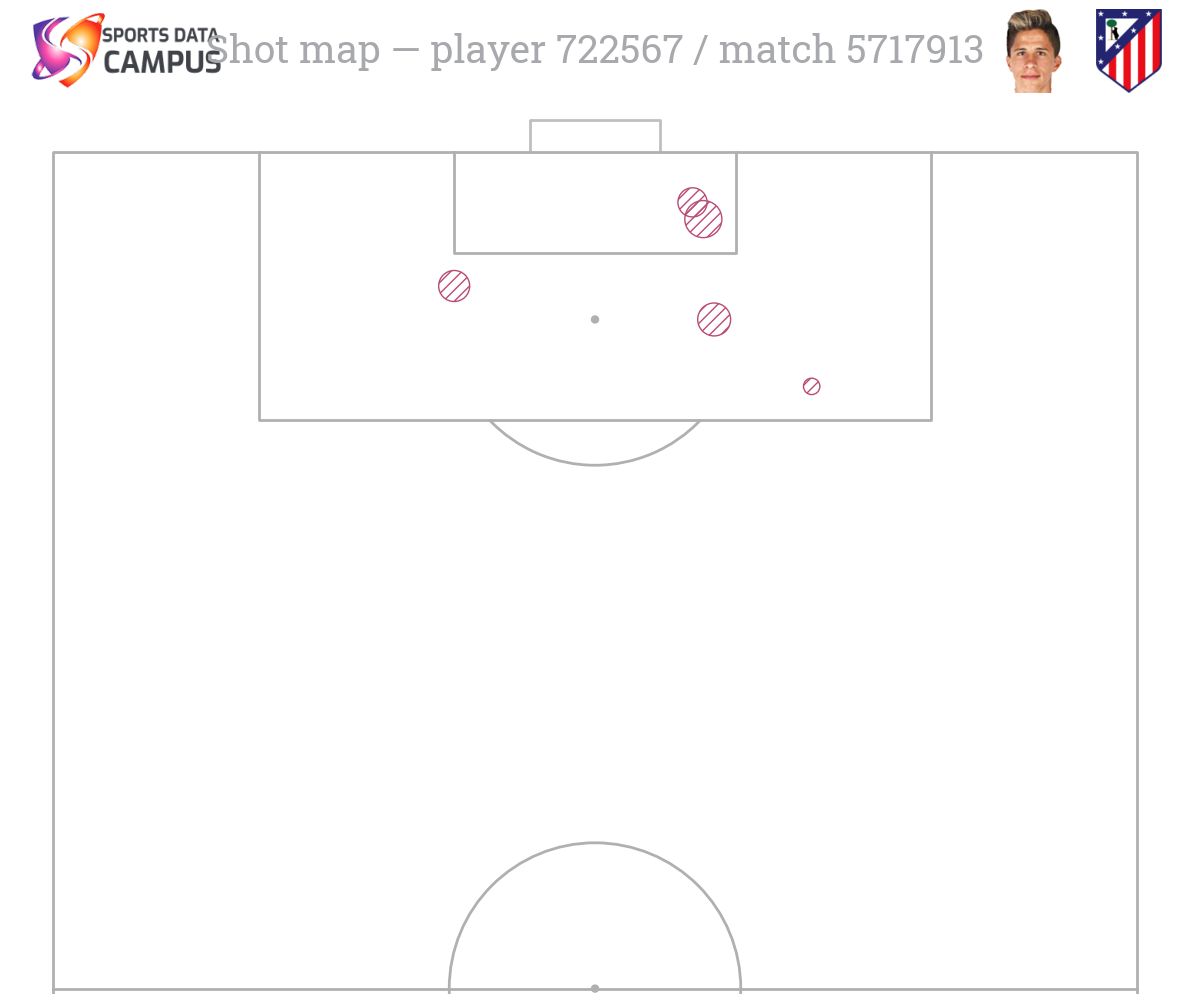

In [40]:
prompt = """
Trova uno o più match_id in `gold_match_shot_event` per player_id 722567 (progetto/dataset già noti).
Poi crea la shot map con create_shot_map per match_id 5717913 e player_id 722567.
Chiudi con 3 bullet: volume tiri, xG, zona del campo.
"""

answer, messages = run_data_agent(prompt)
render_agent_response(answer, messages)

In [30]:
# %%
import re

m = re.search(r"path=([^\n]+)", answer)
if m:
    img_path = m.group(1).strip()
    display(Image(filename=img_path))
else:
    display(Markdown("Nessun path immagine trovato nella risposta."))

Nessun path immagine trovato nella risposta.